In [2]:
!pip install anndata
!pip install scanpy

In [9]:
import scanpy as sc
import pandas as pd
import anndata as ad

# 1. Load Galaxy MTX file
adata = sc.read_mtx('matrix.mtx').T

# 2. Load gene names - WE ARE FIXING THIS LINE
genes = pd.read_csv('genes.tsv', header=None, sep='\t')

# USE genes[1] instead of genes[0] to get symbols like 'PLCXD1'
adata.var_names = genes[1].values

# Make names unique (necessary because some Ensembl IDs share one symbol)
adata.var_names_make_unique()

# 3. Load cell barcodes
barcodes = pd.read_csv('barcodes.tsv', header=None, sep='\t')
adata.obs_names = barcodes[0].values
adata.obs_names_make_unique()

# 4. Add the dummy sample column for the author's code
adata.obs['sample'] = 'Galaxy_Sample'

print("Success! Current Gene Names:")
print(adata.var_names[:10])

Success! Current Gene Names:
Index(['LL0YNC03-29C1.1', 'PLCXD1', 'GTPBP6', 'LINC00685', 'PPP2R3B',
       'AL732314.1', 'FABP5P13', 'KRT18P53', 'SHOX', 'RP11-309M23.1'],
      dtype='object')


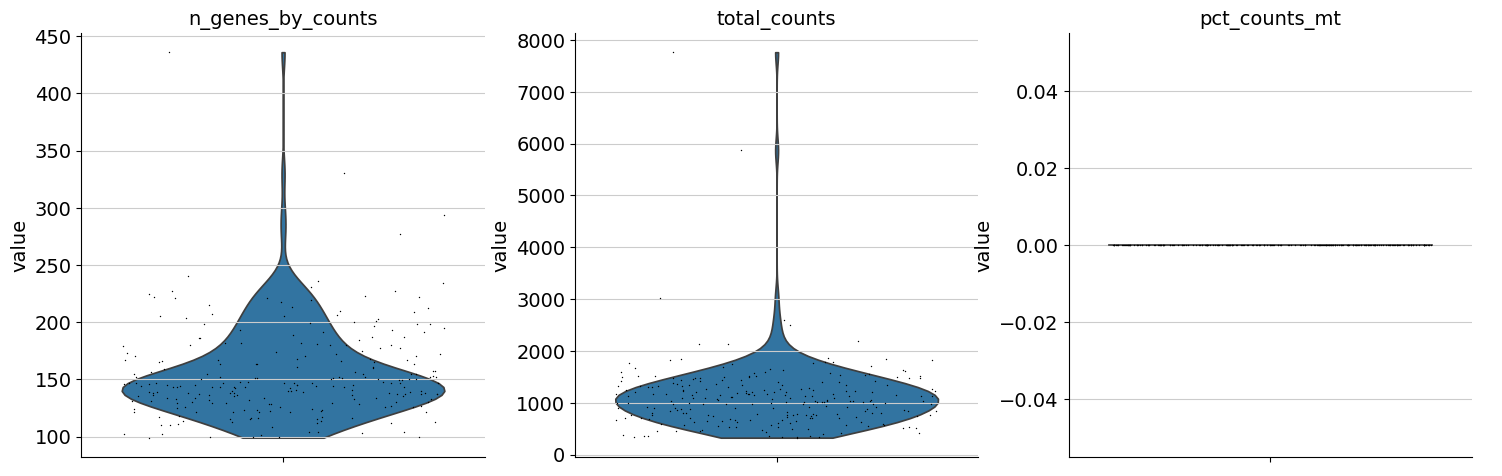

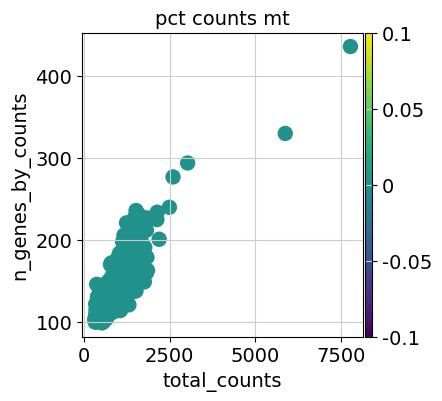

In [11]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")  # "MT-" for human, "Mt-" for mouse
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

# Visualize
sc.pl.violin(adata,["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

# Filter
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [8]:
print(adata.var_names[:20])

Index(['ENSG00000182378', 'ENSG00000178605', 'ENSG00000226179',
       'ENSG00000167393', 'ENSG00000185960', 'ENSG00000225661',
       'ENSG00000198223', 'ENSG00000265350', 'ENSG00000185291',
       'ENSG00000169100', 'ENSG00000236871', 'ENSG00000169093',
       'ENSG00000182162', 'ENSG00000197976', 'ENSG00000169084',
       'ENSG00000223571', 'ENSG00000214717', 'ENSG00000223773',
       'ENSG00000002586', 'ENSG00000235483'],
      dtype='object')


In [5]:
!pip install scrublet
sc.external.pp.scrublet(adata, batch_key="sample")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 12.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=551811 sha256=9f25f7caf9fa78516c8c201f2470aa5c2a475d8f7129bf4a3a26c3303dd47fb7
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


/tmp/ipykernel_623/4283844998.py:2: FutureWarning: Import from sc.pp instead
  sc.external.pp.scrublet(adata, batch_key="sample")


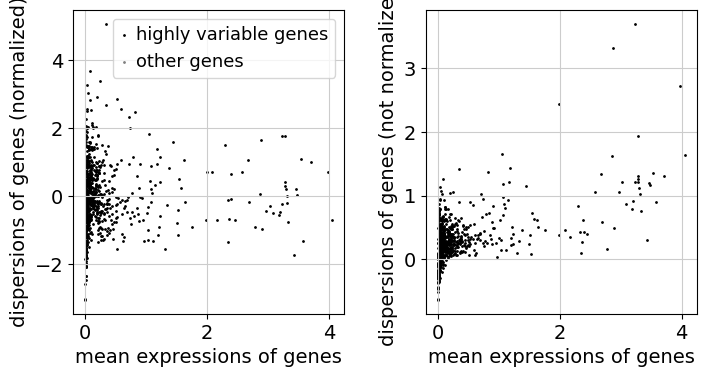

In [12]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data:
sc.pp.log1p(adata)

# Highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.pl.highly_variable_genes(adata)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 9.1 MB/s eta 0:00:00


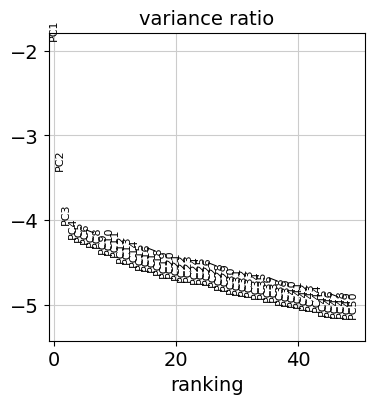

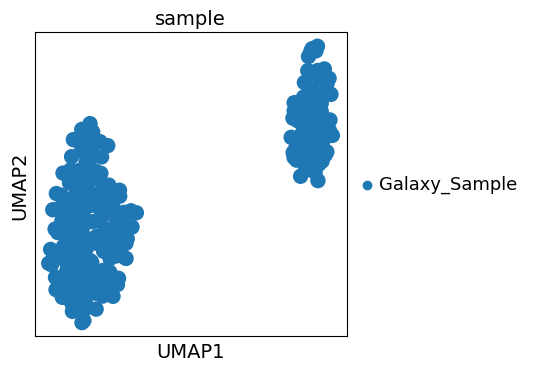

/tmp/ipykernel_623/1151292868.py:14: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


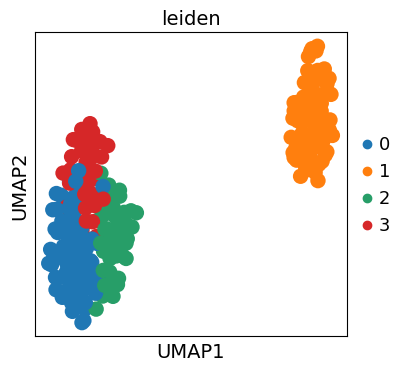

In [13]:
!pip install leidenalg
!pip install --upgrade scanpy igraph leidenalg

# PCA
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

# UMAP
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color="sample")

# Clustering
sc.tl.leiden(adata)
sc.pl.umap(adata, color=["leiden"])

Current cell count before processing: 244
ℹ️ Scrublet did not generate data (common for small datasets).
ℹ️ Skipping doublet removal and moving straight to visualization.


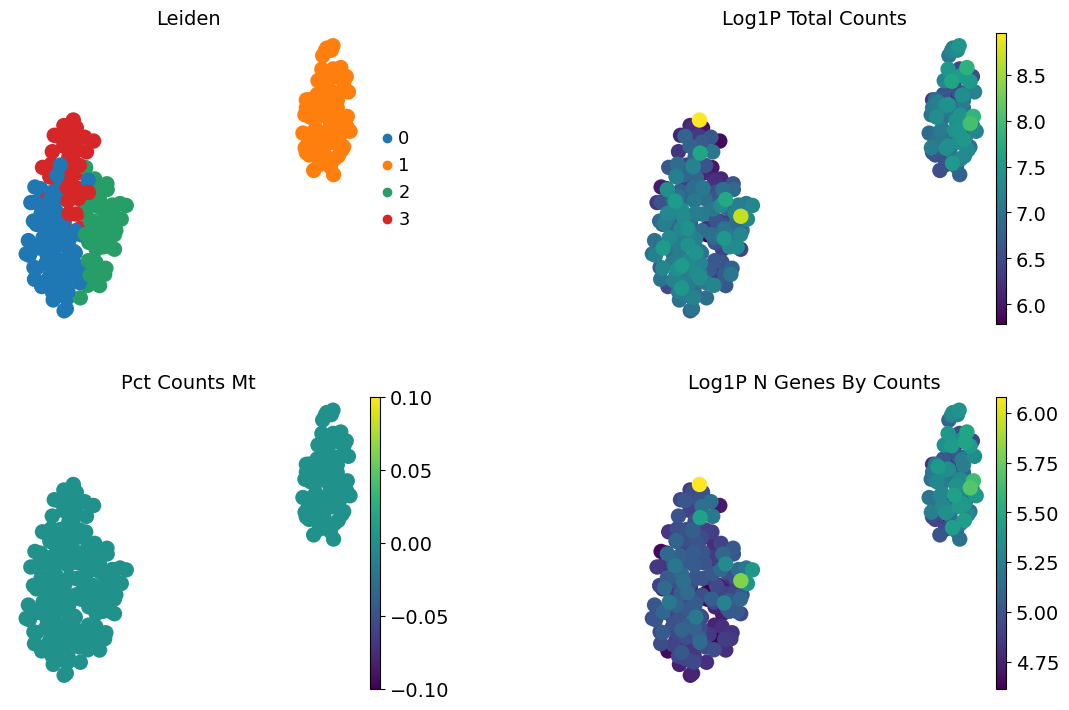

In [20]:
# 1. Define the metrics we want to visualize
# We start with the guaranteed columns
plot_colors = ["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"]

print(f"Current cell count before processing: {adata.n_obs}")

# 2. Handle Doublets dynamically
if 'predicted_doublet' in adata.obs.columns:
    # Logic if Scrublet worked
    adata.obs["predicted_doublet"] = adata.obs["predicted_doublet"].astype("category")

    # Optional: add doublet info to our plot list since it exists
    plot_colors.extend(["predicted_doublet", "doublet_score"])

    # Perform the filtering
    adata = adata[~adata.obs["predicted_doublet"].to_numpy()].copy()

    print(f"✅ Scrublet results found. Doublets removed.")
    print(f"✅ Final cell count: {adata.n_obs}")
else:
    # Logic if Scrublet was skipped (small dataset)
    print("ℹ️ Scrublet did not generate data (common for small datasets).")
    print("ℹ️ Skipping doublet removal and moving straight to visualization.")

# 3. Clean the plot list
# (This ensures we only try to plot columns that actually exist in your data)
final_plot_list = [c for c in plot_colors if c in adata.obs.columns]

# 4. Generate the UMAP
sc.pl.umap(
    adata,
    color=final_plot_list,
    wspace=0.6,
    ncols=2,
    frameon=False,
    title=[c.replace('_', ' ').title() for c in final_plot_list] # Makes titles look pretty
)

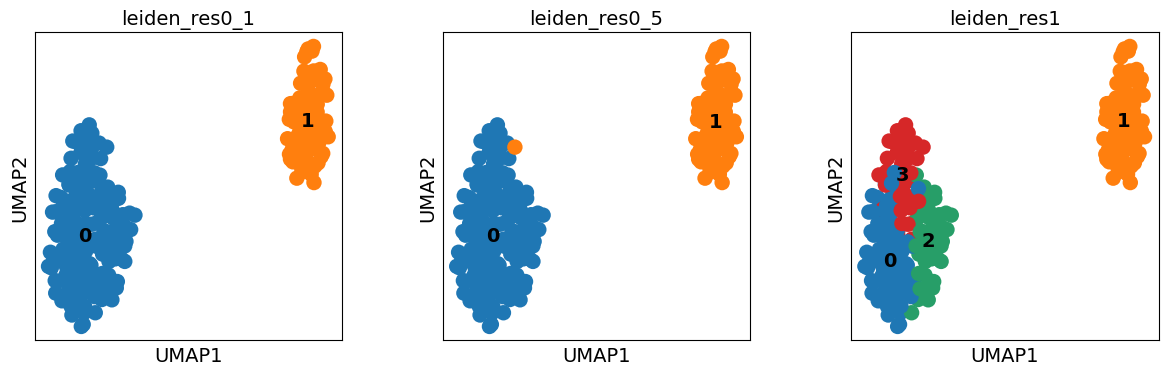

In [22]:
# 1. Clustering at different granularities
sc.tl.leiden(adata, key_added="leiden_res0_1", resolution=0.1) # Broad groups
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5) # Standard (Usually best for you)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)   # High detail

# Visualize them side-by-side
sc.pl.umap(
    adata,
    color=["leiden_res0_1", "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
    ncols=3
)

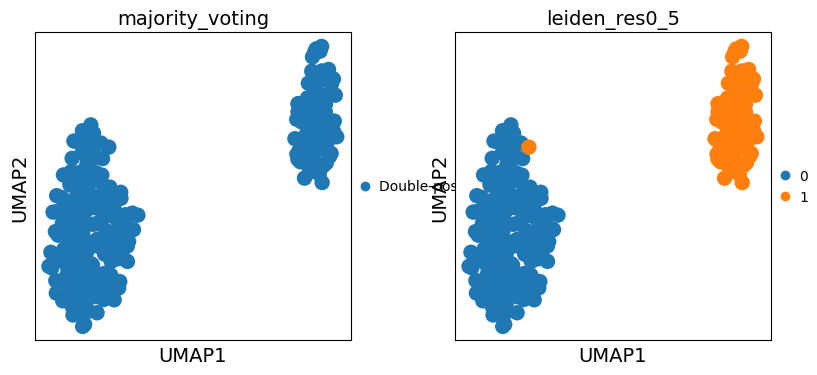

In [23]:
!pip install celltypist

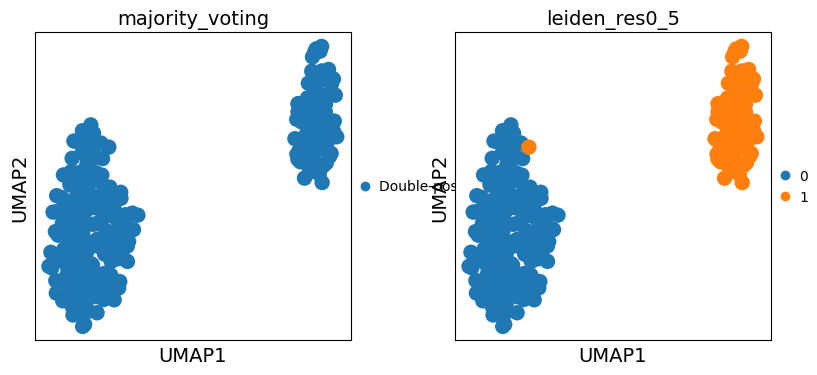

In [25]:
import celltypist as ct

# 1. Download the immune model (Most common for scRNA tutorials)
ct.models.download_models(model=["Immune_All_Low.pkl"], force_update=True)

# 2. Run prediction
# We use 'majority_voting' to make sure cells in the same cluster get the same label
predictions = ct.annotate(adata, model="Immune_All_Low.pkl", majority_voting=True, over_clustering="leiden_res0_5")

# 3. Add the results back to your data
adata = predictions.to_adata()

# 4. Plot the results!
sc.pl.umap(adata, color=["majority_voting", "leiden_res0_5"], legend_loc="right margin")

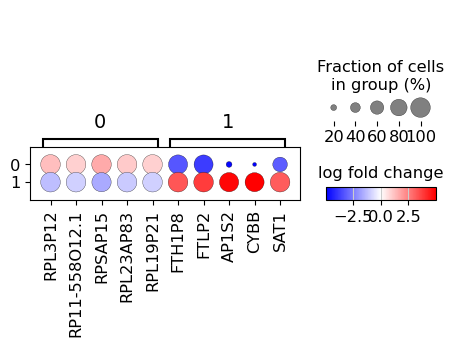

In [24]:
# 1. Calculate top genes for each cluster
sc.tl.rank_genes_groups(adata, 'leiden_res0_5', method='wilcoxon')

# 2. Plot the top 5 genes per cluster in a DotPlot
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, values_to_plot='logfoldchanges', cmap='bwr')

In [26]:
print(adata)

AnnData object with n_obs × n_vars = 244 × 751
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden', 'leiden_res0_02', 'leiden_res0_5', 'leiden_res2', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'leiden_res0_1', 'leiden_res1'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'sample_colors', 'leiden', 

In [27]:
adata.obs.head()

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,leiden,leiden_res0_02,leiden_res0_5,leiden_res2,predicted_labels,over_clustering,majority_voting,conf_score,leiden_res0_1,leiden_res1
AAAGAACCAATGGCAG,Galaxy_Sample,104,4.653960,325.0,5.786897,83.384615,98.769231,100.000000,100.0,0.0,...,0,0,0,7,Epithelial cells,0,Double-positive thymocytes,0.008732,0,0
AAAGGATAGTAGACAT,Galaxy_Sample,151,5.023881,1494.0,7.309882,90.763052,96.586345,100.000000,100.0,0.0,...,2,0,0,0,B cells,0,Double-positive thymocytes,0.035483,0,2
AAAGGATCACCGGCTA,Galaxy_Sample,124,4.828314,845.0,6.740520,90.177515,97.159763,100.000000,100.0,0.0,...,2,0,0,0,Double-positive thymocytes,0,Double-positive thymocytes,0.007415,0,2
AAAGGATTCCGTTTCG,Galaxy_Sample,203,5.318120,1658.0,7.413970,83.112183,92.943305,99.819059,100.0,0.0,...,1,1,1,1,Double-positive thymocytes,1,Double-positive thymocytes,0.017243,1,1
AAAGTCCCACCAGCCA,Galaxy_Sample,201,5.308268,2195.0,7.694393,87.835991,95.125285,99.954442,100.0,0.0,...,2,0,0,0,Double-positive thymocytes,0,Double-positive thymocytes,0.034010,0,2
